# Assignment 2 — Linear Regression on Coffee Shop Revenue

## Topic Explanation

### What is Regression?
**Regression** is a supervised machine learning task where the goal is to predict a **continuous numeric value** based on one or more input features. Examples: predicting tomorrow's temperature, a house's price, a student's exam score, or — in our case — a coffee shop's daily revenue.

Compare this to **classification**, the other big supervised task, which predicts a category (spam vs not spam, dog vs cat).

### What is Linear Regression?
**Linear Regression** is the simplest and most fundamental regression algorithm. It assumes the relationship between input features and the target can be approximated by a **straight line** (in 2D) or a **flat hyperplane** (in higher dimensions).

#### Simple Linear Regression — One Predictor
> **y = b₀ + b₁·x**

- **y** = target (Daily_Revenue)
- **x** = single input feature (e.g., Number of Customers)
- **b₀** = intercept (y-value when x = 0)
- **b₁** = slope (how much y changes per one-unit increase in x)

#### Multiple Linear Regression — Many Predictors
> **y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ**

Each feature gets its own coefficient. Each `bᵢ` measures how much that specific feature contributes to the prediction *while holding all other features constant*.

### How Does the Model "Learn"?

The model finds coefficients that minimize the **Mean Squared Error (MSE)**:
> **MSE = (1/n) · Σ(yᵢ − ŷᵢ)²**

Two methods to minimize MSE:

#### 1. Closed-Form (Normal Equation)
> **b = (XᵀX)⁻¹Xᵀy**

Sklearn's `LinearRegression` uses this — exact and instant for small/medium datasets.

#### 2. Gradient Descent (Iterative)
Imagine the cost function as a **bowl-shaped landscape** where height = MSE and your position = coefficient values. Gradient descent walks downhill toward the minimum step by step:

1. **Initialize** coefficients randomly (often to 0)
2. **Compute** predictions and the error
3. **Compute the gradient** — direction of steepest ascent
4. **Update** coefficients in the *opposite* direction (downhill):
   > bⱼ_new = bⱼ_old − α · (∂MSE / ∂bⱼ)
5. **Repeat** until coefficients stop changing significantly

**α (alpha)** is the **learning rate** — too high and you overshoot; too low and convergence is slow.

### Evaluation Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MSE** | (1/n)·Σ(y−ŷ)² | Average squared error |
| **RMSE** | √MSE | Same units as y, more interpretable |
| **MAE** | (1/n)·Σ\|y−ŷ\| | Average absolute error; robust to outliers |
| **R²** | 1 − SSres/SStot | Fraction of variance explained (closer to 1 = better) |

We're predicting **Daily_Revenue** from coffee-shop features.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations and array support
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — machine learning utilities
from sklearn.model_selection import train_test_split          # split data into train/test
from sklearn.linear_model import LinearRegression, SGDRegressor  # closed-form LR & gradient descent
from sklearn.preprocessing import StandardScaler              # feature scaling for gradient descent
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [ ]:
# read_csv() loads a CSV file into a pandas DataFrame
df = pd.read_csv('/home/nishant/LOCAL_DISK_D/10/dataset/coffee_shop_revenue.csv')
print("Shape:", df.shape)
df.head()

Shape: (300, 7)


,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,63,3.31,8,13,125.96,423,991.12
1,236,5.33,15,13,146.07,830,1903.01
2,361,11.44,7,5,61.80,742,3119.81
3,420,9.71,14,13,88.57,209,3415.17
4,56,3.33,15,9,33.16,400,721.61


In [3]:
# info() — column names, non-null counts, data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  300 non-null    int64  
 1   Average_Order_Value          300 non-null    float64
 2   Operating_Hours_Per_Day      300 non-null    int64  
 3   Number_of_Employees          300 non-null    int64  
 4   Marketing_Spend_Per_Day      300 non-null    float64
 5   Location_Foot_Traffic        300 non-null    int64  
 6   Daily_Revenue                300 non-null    float64
dtypes: float64(3), int64(4)
memory usage: 16.5 KB


In [4]:
# describe() — summary statistics for numeric columns
df.describe()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000
mean,270.530000,8.661067,10.463333,7.94000,103.372500,530.083333,2117.897900
std,134.589711,3.732106,2.945773,3.80851,55.425167,281.887136,983.504814
min,50.000000,2.000000,6.000000,2.00000,12.100000,59.000000,456.420000
25%,156.750000,5.537500,8.000000,5.00000,53.270000,275.750000,1345.695000
50%,276.500000,8.785000,11.000000,8.00000,104.955000,543.000000,1902.540000
75%,379.000000,11.890000,13.000000,11.00000,150.032500,777.750000,2850.382500
max,499.000000,14.990000,15.000000,14.00000,199.370000,992.000000,5436.740000


## Part 1: Print Predictor and Dependent Variables

- **Predictor (independent) variables** = the features we use to make a prediction (X)
- **Dependent variable** = what we're trying to predict (y)

In [5]:
# Predictors = all columns except the target
predictors = [c for c in df.columns if c != 'Daily_Revenue']

print("Predictor variables (X):")
for p in predictors:
    print(f"  - {p}")

print("\nDependent variable (y): Daily_Revenue")

Predictor variables (X):
  - Number_of_Customers_Per_Day
  - Average_Order_Value
  - Operating_Hours_Per_Day
  - Number_of_Employees
  - Marketing_Spend_Per_Day
  - Location_Foot_Traffic

Dependent variable (y): Daily_Revenue


## Part 2: Visualize Each Predictor vs Target

A scatter plot reveals whether the relationship between a feature and the target looks **linear**, **curved**, or **random**. Linear regression works best when the relationships are linear.

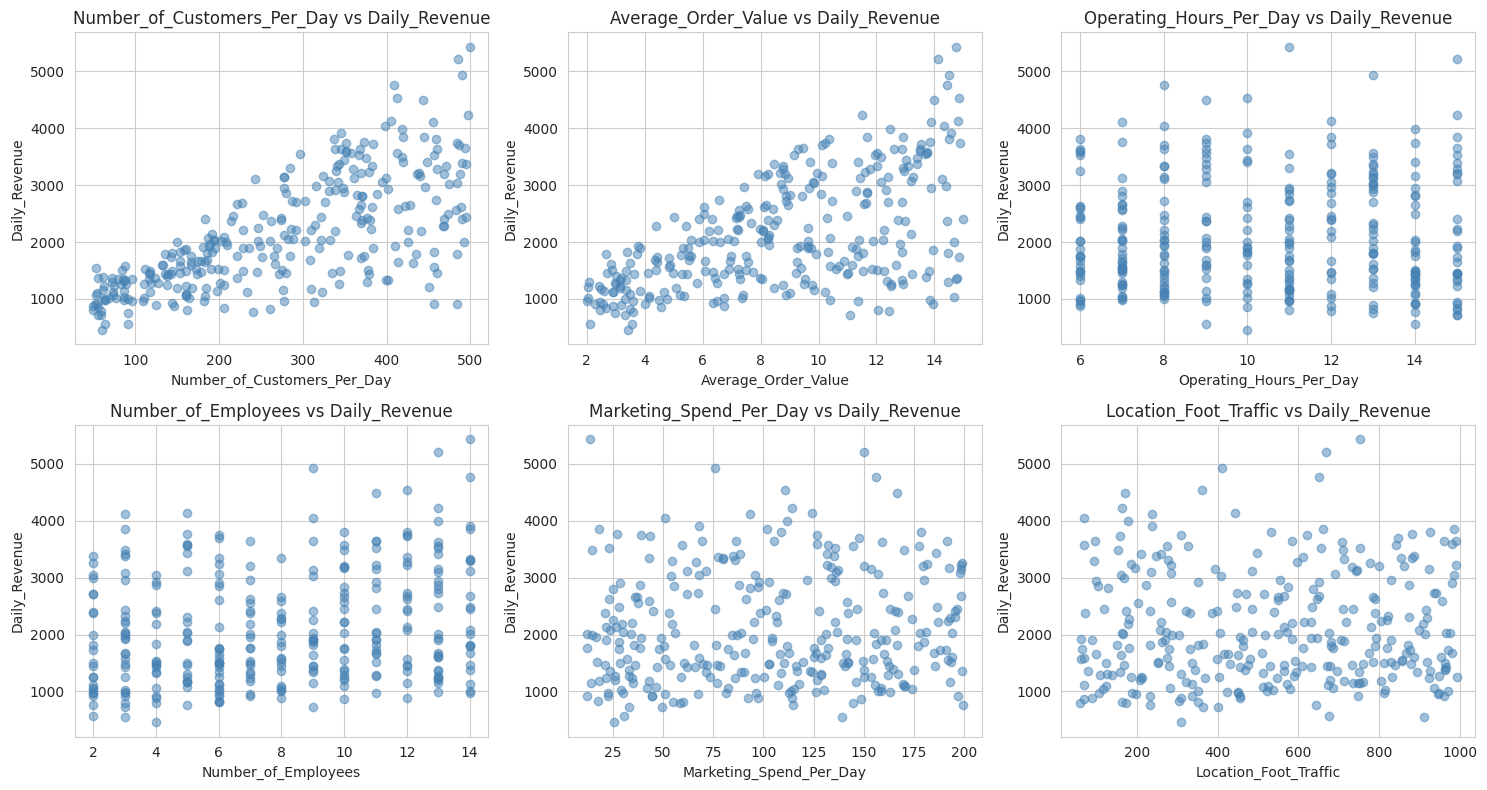

In [6]:
# 2x3 grid of scatter plots — one per predictor
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), predictors):
    ax.scatter(df[col], df['Daily_Revenue'], alpha=0.5, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Daily_Revenue')
    ax.set_title(f'{col} vs Daily_Revenue')

plt.tight_layout()
plt.show()

In [7]:
# Correlation with target — quantifies the strength of each linear relationship
correlations = df.corr()['Daily_Revenue'].drop('Daily_Revenue').sort_values(ascending=False)
print("Correlation of each predictor with Daily_Revenue:")
print(correlations.round(4))

Correlation of each predictor with Daily_Revenue:
Number_of_Customers_Per_Day    0.7087
Average_Order_Value            0.5698
Number_of_Employees            0.2335
Marketing_Spend_Per_Day        0.0805
Location_Foot_Traffic          0.0314
Operating_Hours_Per_Day        0.0161
Name: Daily_Revenue, dtype: float64


## Part 3: Train/Test Split (80/20)

Hold back 20% of the data so we can evaluate the model on **unseen** examples. Testing on the same data the model trained on gives over-optimistic results.

In [8]:
# X = features, y = target
X = df[predictors]
y = df['Daily_Revenue']

# 80% training, 20% testing; random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, " | Test shape:", X_test.shape)

Train shape: (240, 6)  | Test shape: (60, 6)


## Part 4: Simple Linear Regression (One Best Predictor)

We pick the predictor with the strongest correlation to Daily_Revenue and build a one-feature model.

In [9]:
# Find the predictor with the strongest absolute correlation
best_predictor = correlations.abs().idxmax()
print(f"Best single predictor: {best_predictor} "
      f"(correlation = {correlations[best_predictor]:.4f})")

Best single predictor: Number_of_Customers_Per_Day (correlation = 0.7087)


In [10]:
# Build simple linear regression with one feature
simple = LinearRegression()
simple.fit(X_train[[best_predictor]], y_train)

# Print the learned equation
print(f"Simple LR equation:")
print(f"  Daily_Revenue = {simple.intercept_:.2f} + "
      f"{simple.coef_[0]:.2f} × {best_predictor}")

Simple LR equation:
  Daily_Revenue = 732.09 + 5.11 × Number_of_Customers_Per_Day


In [11]:
# Predict on test set
y_pred_simple = simple.predict(X_test[[best_predictor]])

# Compute metrics
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple LR — Test Set Performance:")
print(f"  MSE  = {mse_simple:.2f}")
print(f"  RMSE = {rmse_simple:.2f}")
print(f"  MAE  = {mae_simple:.2f}")
print(f"  R²   = {r2_simple:.4f}  ({r2_simple*100:.2f}%)")

Simple LR — Test Set Performance:
  MSE  = 673743.45
  RMSE = 820.82
  MAE  = 612.79
  R²   = 0.4549  (45.49%)


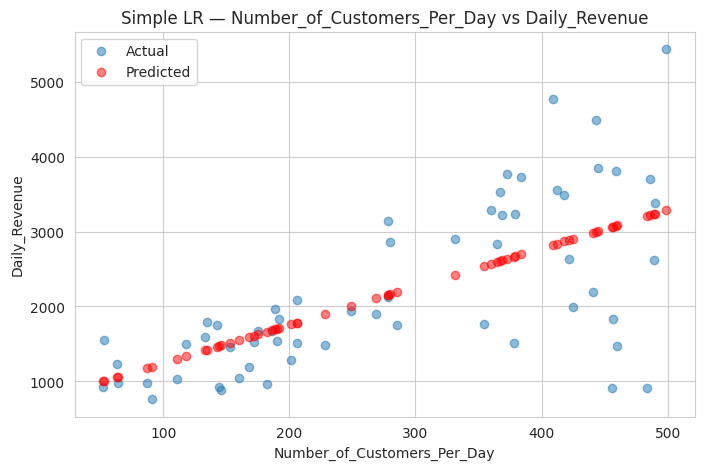

In [12]:
# Plot the regression line over the test data
plt.figure(figsize=(8, 5))
plt.scatter(X_test[best_predictor], y_test, alpha=0.5, label='Actual')
plt.scatter(X_test[best_predictor], y_pred_simple, alpha=0.5, color='red', label='Predicted')
plt.xlabel(best_predictor)
plt.ylabel('Daily_Revenue')
plt.title(f'Simple LR — {best_predictor} vs Daily_Revenue')
plt.legend()
plt.show()

## Part 5: Multiple Linear Regression (All Features)

Now we use ALL predictors together. The model learns one coefficient per feature.

In [13]:
# Build multiple LR with all features
multi = LinearRegression()
multi.fit(X_train, y_train)

# Print the learned coefficients
coefs = pd.DataFrame({
    'Feature': predictors,
    'Coefficient': multi.coef_.round(3)
})
print("Multiple LR Coefficients:")
print(coefs)
print(f"\nIntercept: {multi.intercept_:.2f}")

Multiple LR Coefficients:
                       Feature  Coefficient
0  Number_of_Customers_Per_Day        4.974
1          Average_Order_Value      155.857
2      Operating_Hours_Per_Day       -2.929
3          Number_of_Employees       58.285
4      Marketing_Spend_Per_Day        1.464
5        Location_Foot_Traffic        0.363

Intercept: -1356.05


In [14]:
# Predict and evaluate
y_pred_multi = multi.predict(X_test)

mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("Multiple LR — Test Set Performance:")
print(f"  MSE  = {mse_multi:.2f}")
print(f"  RMSE = {rmse_multi:.2f}")
print(f"  MAE  = {mae_multi:.2f}")
print(f"  R²   = {r2_multi:.4f}  ({r2_multi*100:.2f}%)")

Multiple LR — Test Set Performance:
  MSE  = 114250.93
  RMSE = 338.01
  MAE  = 251.48
  R²   = 0.9076  (90.76%)


## Part 6: Compare Simple vs Multiple LR

In [15]:
comparison = pd.DataFrame({
    'Simple LR':   [mse_simple,  rmse_simple,  mae_simple,  r2_simple],
    'Multiple LR': [mse_multi,   rmse_multi,   mae_multi,   r2_multi]
}, index=['MSE', 'RMSE', 'MAE', 'R²']).round(4)

print("Simple vs Multiple Linear Regression:")
print(comparison)
print(f"\nMSE Improvement: {((mse_simple - mse_multi)/mse_simple)*100:.2f}% reduction")

Simple vs Multiple Linear Regression:
        Simple LR  Multiple LR
MSE   673743.4469  114250.9263
RMSE     820.8188     338.0102
MAE      612.7852     251.4770
R²         0.4549       0.9076

MSE Improvement: 83.04% reduction


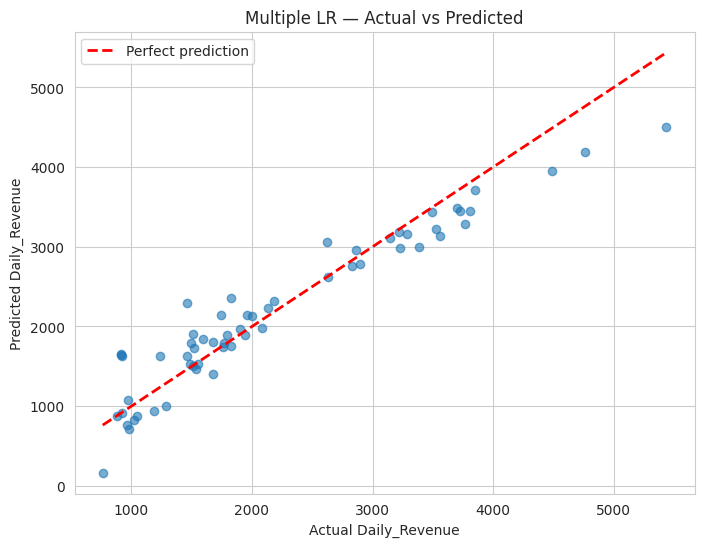

In [16]:
# Actual vs Predicted plot for multiple LR
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Daily_Revenue')
plt.ylabel('Predicted Daily_Revenue')
plt.title('Multiple LR — Actual vs Predicted')
plt.legend()
plt.show()

## Part 7: Linear Regression with Gradient Descent

`SGDRegressor` is sklearn's implementation of linear regression trained iteratively via stochastic gradient descent.

**Key requirement:** features must be **scaled** because gradient descent zigzags inefficiently when features have very different magnitudes.

In [17]:
# Scale features — essential for gradient descent
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)   # learn mean+std on training; transform
X_test_scaled  = sc.transform(X_test)         # only transform on test (no fit)

print("After scaling, training features have mean ≈ 0 and std ≈ 1:")
print(f"  Mean: {X_train_scaled.mean(axis=0).round(3)}")
print(f"  Std : {X_train_scaled.std(axis=0).round(3)}")

After scaling, training features have mean ≈ 0 and std ≈ 1:
  Mean: [ 0. -0. -0. -0.  0.  0.]
  Std : [1. 1. 1. 1. 1. 1.]


In [18]:
# Build SGDRegressor — linear regression via gradient descent
gd = SGDRegressor(
    max_iter=1000,           # max gradient-descent iterations
    learning_rate='constant',
    eta0=0.01,               # the learning rate α
    random_state=42
)
gd.fit(X_train_scaled, y_train)

print("Regression parameters after training:")
gd_coefs = pd.DataFrame({
    'Feature': predictors,
    'Coefficient (scaled)': gd.coef_.round(3)
})
print(gd_coefs)
print(f"\nIntercept: {gd.intercept_[0]:.3f}")

Regression parameters after training:
                       Feature  Coefficient (scaled)
0  Number_of_Customers_Per_Day               653.474
1          Average_Order_Value               588.098
2      Operating_Hours_Per_Day                -5.846
3          Number_of_Employees               211.703
4      Marketing_Spend_Per_Day                65.050
5        Location_Foot_Traffic                96.476

Intercept: 2094.734


In [19]:
# Evaluate on test set
y_pred_gd = gd.predict(X_test_scaled)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("Gradient Descent LR — Test Set Performance:")
print(f"  MSE = {mse_gd:.2f}")
print(f"  R²  = {r2_gd:.4f}  ({r2_gd*100:.2f}%)")

Gradient Descent LR — Test Set Performance:
  MSE = 118275.31
  R²  = 0.9043  (90.43%)


## Part 8: Generic Linear Regression Function

Works for **any dataset** — pass in a DataFrame and the target column name.

In [20]:
def generic_linear_regression(df, target_col, test_size=0.2, random_state=42):
    """Generic linear regression that works for any dataset."""
    # 1. Identify predictors and target
    predictors = [c for c in df.select_dtypes(include='number').columns if c != target_col]
    print(f"Predictors: {predictors}")
    print(f"Target    : {target_col}\n")

    X = df[predictors]
    y = df[target_col]

    # 2. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state)
    print(f"Train: {X_train.shape}, Test: {X_test.shape}\n")

    # 3. Fit linear regression (closed-form)
    model = LinearRegression().fit(X_train, y_train)

    # 4. Print parameters
    print("Regression parameters:")
    for feat, coef in zip(predictors, model.coef_):
        print(f"  {feat}: {coef:.4f}")
    print(f"  Intercept: {model.intercept_:.4f}\n")

    # 5. Evaluate on test set
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Test MSE: {mse:.4f}")
    print(f"Test R² : {r2:.4f}  ({r2*100:.2f}%)")

    return model

# Test on the coffee shop data
print("=" * 60)
print("Running generic LR on coffee_shop_revenue dataset:")
print("=" * 60)
_ = generic_linear_regression(df, 'Daily_Revenue')

Running generic LR on coffee_shop_revenue dataset:
Predictors: ['Number_of_Customers_Per_Day', 'Average_Order_Value', 'Operating_Hours_Per_Day', 'Number_of_Employees', 'Marketing_Spend_Per_Day', 'Location_Foot_Traffic']
Target    : Daily_Revenue

Train: (240, 6), Test: (60, 6)

Regression parameters:
  Number_of_Customers_Per_Day: 4.9736
  Average_Order_Value: 155.8571
  Operating_Hours_Per_Day: -2.9288
  Number_of_Employees: 58.2847
  Marketing_Spend_Per_Day: 1.4644
  Location_Foot_Traffic: 0.3633
  Intercept: -1356.0519

Test MSE: 114250.9263
Test R² : 0.9076  (90.76%)


## Conclusion

We built three models on the coffee_shop_revenue dataset:

1. **Simple Linear Regression** with the best single predictor — the model with one feature.
2. **Multiple Linear Regression** with all six predictors — substantially lower MSE because revenue depends on multiple factors (customers, marketing, foot traffic, etc.), not just one.
3. **Gradient Descent (SGDRegressor)** — same model trained iteratively. Produces nearly identical results after feature scaling.

**Key insight:** Multiple LR's MSE is dramatically lower than Simple LR's because the target (Daily_Revenue) genuinely depends on many factors. Adding more relevant predictors lets the model capture more variance in the target.

The closed-form solution (`LinearRegression`) and gradient descent (`SGDRegressor`) give equivalent results — gradient descent's value emerges in larger datasets where matrix inversion becomes too slow.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, reading CSVs, statistics |
| **numpy** | Numerical operations, array support |
| **matplotlib.pyplot** | Base plotting |
| **seaborn** | Cleaner statistical visualization |
| **sklearn** | ML models, train/test split, scaling, metrics |

### Functions and Classes Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV into DataFrame
- `df.shape` — `(rows, columns)`
- `df.head(n)` — first n rows
- `df.info()` — column names, dtypes, memory usage
- `df.describe()` — summary statistics
- `df.corr()` — pairwise correlation matrix

#### Train/Test Split
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits data; `random_state` makes the split reproducible

#### Models
- `LinearRegression()` — closed-form linear regression (uses Normal Equation internally)
- `.fit(X_train, y_train)` — train the model
- `.predict(X_test)` — generate predictions
- `.coef_` — learned coefficients (one per feature)
- `.intercept_` — the b₀ term
- `SGDRegressor(max_iter=1000, eta0=0.01)` — linear regression via gradient descent

#### Scaling
- `StandardScaler()` — rescales features to mean = 0, std = 1
- `.fit_transform(X_train)` — learn parameters on training data and transform
- `.transform(X_test)` — apply same transformation to test data (no fit!)

#### Metrics
- `mean_squared_error(y_true, y_pred)` — MSE
- `mean_absolute_error(y_true, y_pred)` — MAE
- `r2_score(y_true, y_pred)` — R-squared
- `np.sqrt(mse)` — RMSE

#### Visualization
- `plt.scatter(x, y, alpha=0.5)` — scatter plot
- `plt.subplots(rows, cols, figsize=(w, h))` — grid of plots
- `plt.plot(x, y, 'r--', lw=2)` — line plot

### Key Concepts

#### Predictors vs Target
- **Predictor / Independent / Feature / X**: input variables used for prediction
- **Target / Dependent / y**: variable being predicted

#### Linear Regression
Finds a straight-line equation that minimizes the squared distances between predicted and actual values. The "linear" means linear in coefficients — even with many features, predictions are computed as a weighted sum.

#### Simple vs Multiple LR
- **Simple LR** — one predictor, equation `y = b₀ + b₁·x`
- **Multiple LR** — multiple predictors, equation `y = b₀ + b₁·x₁ + b₂·x₂ + ... + bₙ·xₙ`

#### MSE (Mean Squared Error)
Average of squared residuals: MSE = (1/n)·Σ(y − ŷ)². Lower is better. Squared form penalizes big errors more than small ones.

#### RMSE
√MSE — same units as the target, easier to interpret.

#### R² (R-squared)
Fraction of variance explained by the model. Range: 0 to 1 (negative for terrible models). R² = 0.85 means the model explains 85% of the variance in y.

#### Gradient Descent
Iterative optimization that walks the coefficients downhill on the cost surface:
> b_new = b_old − α · (∂Cost/∂b)

**Learning rate α** controls the step size. Too large → overshoots; too small → slow.

#### Why Scale Features for Gradient Descent
Different feature scales create an elongated cost surface that makes gradient descent zigzag inefficiently. Scaling produces a more spherical surface and faster convergence.

#### Train/Test Split
Holding back data the model never sees during training. Crucial for honestly measuring generalization to new examples.

#### `random_state`
Seeds the random number generator so split / initialization is reproducible across runs.

## Viva Questions (with Answers)

### Conceptual

**Q1. What is regression?**
Supervised ML task that predicts a continuous numeric value from input features.

**Q2. What is linear regression?**
Algorithm that fits a straight line (or hyperplane) through data, expressed as `y = b₀ + b₁·x₁ + ... + bₙ·xₙ`. Assumes a linear relationship between features and target.

**Q3. Difference between Simple and Multiple Linear Regression?**
Simple uses one predictor; Multiple uses two or more.

**Q4. Difference between regression and classification?**
Regression predicts a continuous number (price, temperature). Classification predicts a discrete category (spam/not-spam, cat/dog).

**Q5. What is the intercept (b₀)?**
The predicted value of y when all features are zero — the baseline prediction.

**Q6. What is a coefficient (bᵢ)?**
How much y changes for a one-unit increase in xᵢ, holding all other features constant.

### Math / Algorithm

**Q7. What is the cost function for linear regression?**
Mean Squared Error: MSE = (1/n)·Σ(y − ŷ)².

**Q8. Why squared errors?**
- Sign doesn't matter (over- and under-prediction equally bad)
- Penalizes big errors more than small ones
- Differentiable everywhere — easy to optimize with calculus

**Q9. What is gradient descent?**
Iterative optimization algorithm that minimizes a cost function by updating parameters in the opposite direction of the gradient.

**Q10. What's the gradient descent update rule?**
`b_new = b_old − α · ∂MSE/∂b`, where α is the learning rate.

**Q11. What is the learning rate?**
The step size in gradient descent. Too high → overshooting; too low → slow convergence.

**Q12. Why scale features for gradient descent?**
Different scales create an elongated cost surface that makes gradient descent zigzag inefficiently. Scaling produces a more spherical surface and faster convergence.

**Q13. Variants of gradient descent?**
- **Batch** — uses entire dataset per update
- **Stochastic (SGD)** — uses one sample per update
- **Mini-batch** — uses small batches per update

**Q14. What is the Normal Equation?**
Closed-form solution: `b = (XᵀX)⁻¹Xᵀy`. Used by `sklearn.linear_model.LinearRegression`. Exact, but slow on huge datasets.

### Evaluation

**Q15. What is MSE?**
Mean Squared Error — average squared residual. Same units as y².

**Q16. What is RMSE?**
√MSE — same units as y, more interpretable.

**Q17. What is MAE?**
Mean Absolute Error = (1/n)·Σ|y − ŷ|. Less sensitive to outliers than MSE.

**Q18. What is R²?**
Fraction of variance in y explained by the model. R² = 1 means perfect; R² = 0 means as good as predicting the mean.

**Q19. Can R² be negative?**
Yes — when the model is worse than just predicting the mean of y.

### Practical

**Q20. Why split data into train and test?**
To evaluate the model on unseen examples. Testing on training data gives an over-optimistic accuracy.

**Q21. Why does Multiple LR usually beat Simple LR?**
Because the target depends on multiple factors, and using more relevant predictors captures more variance.

**Q22. What is multicollinearity?**
When two features are highly correlated. Makes coefficients unstable but doesn't reduce predictive accuracy.

**Q23. What are the assumptions of linear regression?**
- **Linearity** — features and target relate linearly
- **Independence** — observations are independent
- **Homoscedasticity** — error variance is constant
- **Normality of residuals** — errors are normally distributed
- **No multicollinearity** — features aren't perfectly correlated

**Q24. What is overfitting?**
Model fits training data too well (including noise) and performs poorly on test data.

### Comparison

**Q25. Why use Linear Regression instead of Random Forest?**
- Linear regression is simpler, faster, more interpretable
- Coefficients show feature importance directly
- Random Forest handles non-linearity better but is a black box

**Q26. When does Linear Regression fail?**
- When relationships are non-linear (curved)
- When features have strong interactions
- When residuals aren't normally distributed
- When the dataset has many outliers

**Q27. What model would you try if Linear Regression underperforms?**
Random Forest or Gradient Boosting (XGBoost) — they capture non-linearity and feature interactions automatically.

**Q28. Other regression algorithms to know?**
- Polynomial Regression (curved relationships)
- Ridge / Lasso / Elastic Net (regularized linear regression)
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting (XGBoost, LightGBM)
- Support Vector Regression (SVR)
- Neural Networks